In [12]:
!pip install transformers datasets accelerate peft bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 14.5 MB/s eta 0:00:00


In [13]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
import torch
import pandas as pd


In [14]:
from google.colab import files
uploaded = files.upload()


Saving DiseaseAndSymptoms.csv to DiseaseAndSymptoms.csv


In [15]:
df = pd.read_csv("DiseaseAndSymptoms.csv")

def row_to_text(row):
    symptoms = []
    for col in df.columns:
        if col.startswith("Symptom") and pd.notna(row[col]):
            symptoms.append(str(row[col]))
    symptom_text = ", ".join(symptoms)

    return {
        "instruction": "Predict the disease based on symptoms.",
        "input": symptom_text,
        "output": row["Disease"]
    }

jsonl_data = df.apply(row_to_text, axis=1).to_list()


In [16]:
import json
from sklearn.model_selection import train_test_split

train, test = train_test_split(jsonl_data, test_size=0.1, random_state=42)

with open("train.jsonl", "w") as f:
    for item in train:
        f.write(json.dumps(item) + "\n")

with open("test.jsonl", "w") as f:
    for item in test:
        f.write(json.dumps(item) + "\n")

print("train.jsonl and test.jsonl created!")


train.jsonl and test.jsonl created!


In [17]:
dataset = load_dataset(
    "json",
    data_files={"train": "train.jsonl", "test": "test.jsonl"}
)

dataset


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 4428
    })
    test: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 492
    })
})

In [18]:
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [19]:
def tokenize_with_labels(example):
    text = (
        f"Instruction: {example['instruction']}\n"
        f"Input: {example['input']}\n"
        f"Output: {example['output']}"
    )

    tokens = tokenizer(text, truncation=True, max_length=256)
    tokens["labels"] = tokens["input_ids"].copy()  # REQUIRED for training
    return tokens

tokenized = dataset.map(tokenize_with_labels)
print("Tokenization with labels completed!")


Map:   0%|          | 0/4428 [00:00<?, ? examples/s]

Map:   0%|          | 0/492 [00:00<?, ? examples/s]

Tokenization with labels completed!


In [20]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)


In [21]:
training_args = TrainingArguments(
    output_dir="tinyllama_finetuned",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    report_to="none"  # disable W&B, TensorBoard
)


In [22]:
from transformers import DataCollatorForLanguageModeling


In [23]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False  # because we are training a causal LM
)


In [24]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    data_collator=data_collator
)


The model is already on multiple devices. Skipping the move to device specified in `args`.


In [25]:
from transformers import DataCollatorForLanguageModeling
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)


In [26]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    max_length=256,
    return_tensors="pt"
)


In [27]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    data_collator=data_collator,
)


The model is already on multiple devices. Skipping the move to device specified in `args`.


In [28]:
trainer.train()


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2863: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Step,Training Loss
20,1.750300
40,0.914100
60,0.662700
80,0.487300
100,0.348200
120,0.308000
140,0.204900
160,0.182300
180,0.156300
200,0.139000


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2863: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2863: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


TrainOutput(global_step=1108, training_loss=0.17247402189225497, metrics={'train_runtime': 529.0059, 'train_samples_per_second': 16.741, 'train_steps_per_second': 2.094, 'total_flos': 4570174532468736.0, 'train_loss': 0.17247402189225497, 'epoch': 2.0})

In [29]:
model.eval()


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_featu

In [30]:
import torch

def generate_output(symptoms_text):
    prompt = (
        f"Instruction: Predict the disease based on symptoms.\n"
        f"Input: {symptoms_text}\n"
        f"Output:"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=150,
            temperature=0.3,
            do_sample=True
        )

    decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return decoded


In [31]:
import re

def extract_disease(generated_text):
    # Looks for text after "Disease:"
    match = re.search(r"Disease:\s*([A-Za-z0-9_\-\s]+)", generated_text)
    if match:
        return match.group(1).strip()
    return "Unknown"


In [32]:
test_text = """Disease: Typhoid
Explanation: Example explanation
Note: Not medical advice"""

extract_disease(test_text)


'Typhoid\nExplanation'

In [33]:
def generate_output(symptoms_text):
    prompt = (
        f"Instruction: Predict the disease based on symptoms.\n"
        f"Input: {symptoms_text}\n"
        f"Output:\n"
        f"Disease:"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=30,
            temperature=0.3,
            top_p=0.95,
            do_sample=True,
            repetition_penalty=1.1
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "Disease:" in text:
        text = text.split("Disease:", 1)[1]

    text = text.strip().split("\n")[0].split(".")[0]

    return f"Disease: {text.strip()}"


In [34]:
print(generate_output("fever, headache, body pain"))


Disease: Hepatitis C


In [35]:
y_true = []
y_pred = []

for item in test:
    symptoms = item["input"]
    actual = item["output"]

    generated = generate_output(symptoms)
    predicted = extract_disease(generated)

    y_true.append(actual)
    y_pred.append(predicted)

    print("Symptoms:", symptoms)
    print("Actual:", actual)
    print("Predicted:", predicted)
    print("-" * 50)


Symptoms:  skin_rash,  blackheads,  scurring
Actual: Acne
Predicted: Accideanitis
--------------------------------------------------
Symptoms:  skin_rash,  pus_filled_pimples,  blackheads,  scurring
Actual: Acne
Predicted: Acne
--------------------------------------------------
Symptoms:  fatigue,  mood_swings,  weight_loss,  restlessness,  sweating,  diarrhoea,  fast_heart_rate,  excessive_hunger,  muscle_weakness,  irritability,  abnormal_menstruation
Actual: Hyperthyroidism
Predicted: Hyperthyroidism  Symptoms
--------------------------------------------------
Symptoms:  muscle_wasting,  patches_in_throat,  high_fever,  extra_marital_contacts
Actual: AIDS
Predicted: AIDS
--------------------------------------------------
Symptoms: itching,  vomiting,  yellowish_skin,  nausea,  loss_of_appetite,  abdominal_pain,  yellowing_of_eyes
Actual: Chronic cholestasis
Predicted: Chronic cholestasis
--------------------------------------------------
Symptoms:  headache,  chest_pain,  dizziness,

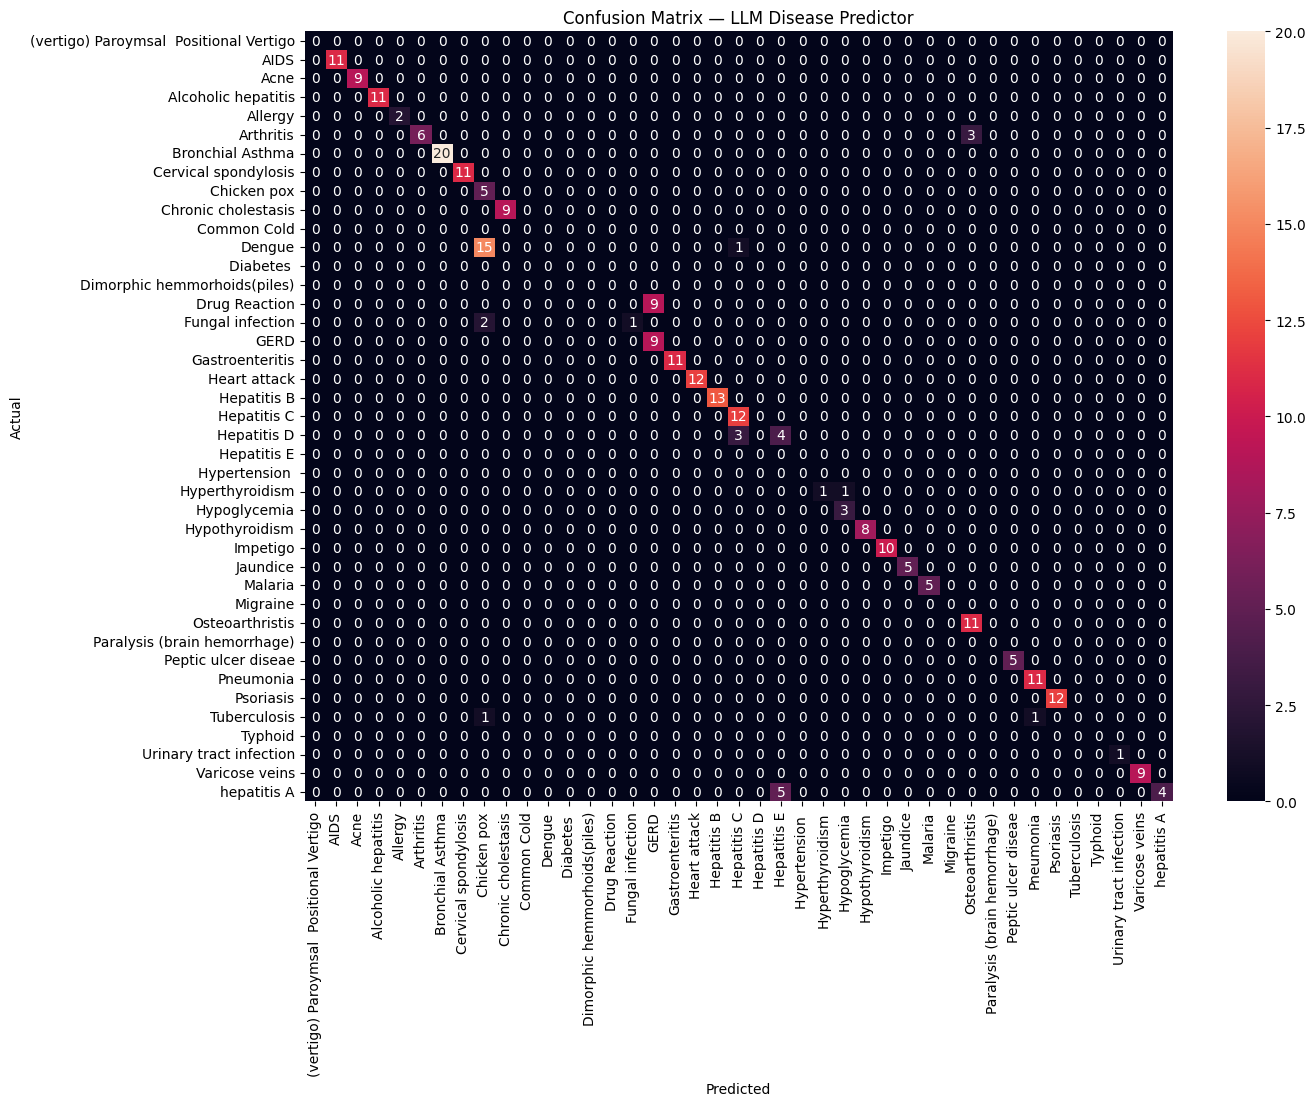

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_true, y_pred, labels=sorted(set(y_true)))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=sorted(set(y_true)),
    yticklabels=sorted(set(y_true))
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — LLM Disease Predictor")
plt.savefig("confusion_matrix.png")
plt.show()


In [37]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


Accuracy: 0.4613821138211382

Classification Report:

                                                                                       precision    recall  f1-score   support

                                              (vertigo) Paroymsal  Positional Vertigo       0.00      0.00      0.00        10
                                                                                 AIDS       1.00      0.85      0.92        13
                                                                         Accideanitis       0.00      0.00      0.00         0
                                                                                 Acne       1.00      0.90      0.95        10
                                                                  Alcoholic Hepatitis       0.00      0.00      0.00         0
                                                                  Alcoholic hepatitis       1.00      0.85      0.92        13
                                     Alcoholic hepatitis

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:
demo = generate_output("fever, headache, body pain")
print(demo)


In [2]:
import torch

def generate_output(symptoms_text):
    prompt = (
        f"Instruction: Identify the disease pattern based on symptoms.\n"
        f"Input: {symptoms_text}\n"
        f"Output:\nDisease:"
    )

    # Tokenize the prompt
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    # Generate output
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=30,
            temperature=0.3,
            top_p=0.95,
            do_sample=True,
            repetition_penalty=1.1
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "Disease:" in text:
        text = text.split("Disease:", 1)[1]

    # Only take the first line of output
    text = text.strip().split("\n")[0].split(".")[0]
    return f"Disease: {text.strip()}\nNote: This is not medical advice. Consult a doctor."


In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",  # automatically assigns GPU
    torch_dtype=torch.float16
)

model.eval()  # set to evaluation mode


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [7]:
def generate_output(symptoms_text):
    prompt = (
        f"Instruction: Identify the disease pattern based on symptoms.\n"
        f"Input: {symptoms_text}\n"
        f"Output:\nDisease:"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=30,
            temperature=0.3,
            top_p=0.95,
            do_sample=True,
            repetition_penalty=1.1
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "Disease:" in text:
        text = text.split("Disease:", 1)[1]

    text = text.strip().split("\n")[0].split(".")[0]
    return f"Disease: {text.strip()}\nNote: This is not medical advice. Consult a doctor."


In [8]:
symptoms_list = [
    "Fever, headache, body pain",
    "Cough, cold, sore throat",
    "Joint pain, swelling"
]

for symptoms in symptoms_list:
    print("Symptoms:", symptoms)
    print(generate_output(symptoms))
    print("-"*50)


Symptoms: Fever, headache, body pain
Disease: Fever and Headache
Note: This is not medical advice. Consult a doctor.
--------------------------------------------------
Symptoms: Cough, cold, sore throat
Disease: Flu
Note: This is not medical advice. Consult a doctor.
--------------------------------------------------
Symptoms: Joint pain, swelling
Disease: Arthritis
Note: This is not medical advice. Consult a doctor.
--------------------------------------------------


In [9]:
!ls -R /content


/content:
confusion_matrix.png	sample_data  tinyllama_finetuned
DiseaseAndSymptoms.csv	test.jsonl   train.jsonl

/content/sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md

/content/tinyllama_finetuned:
checkpoint-1000  checkpoint-1108  checkpoint-500

/content/tinyllama_finetuned/checkpoint-1000:
adapter_config.json	   rng_state.pth	    tokenizer.json
adapter_model.safetensors  scaler.pt		    tokenizer.model
chat_template.jinja	   scheduler.pt		    trainer_state.json
optimizer.pt		   special_tokens_map.json  training_args.bin
README.md		   tokenizer_config.json

/content/tinyllama_finetuned/checkpoint-1108:
adapter_config.json	   rng_state.pth	    tokenizer.json
adapter_model.safetensors  scaler.pt		    tokenizer.model
chat_template.jinja	   scheduler.pt		    trainer_state.json
optimizer.pt		   special_tokens_map.json  training_args.bin
README.md		   tokenizer_config.json

/content/tinyllama_fin

In [10]:
!ls -l /content


total 1804
-rw-r--r-- 1 root root 175719 Dec  3 11:18 confusion_matrix.png
-rw-r--r-- 1 root root 632202 Dec  3 10:59 DiseaseAndSymptoms.csv
drwxr-xr-x 1 root root   4096 Nov 20 14:30 sample_data
-rw-r--r-- 1 root root 103705 Dec  3 10:59 test.jsonl
drwxr-xr-x 5 root root   4096 Dec  3 11:08 tinyllama_finetuned
-rw-r--r-- 1 root root 921407 Dec  3 10:59 train.jsonl


In [13]:
from google.colab import files

files.download("train.jsonl")
files.download("test.jsonl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
import json

with open("test.jsonl", "r") as f:
    test_data = [json.loads(line) for line in f]

print(len(test_data))
print(test_data[:2])


492
[{'instruction': 'Predict the disease based on symptoms.', 'input': ' skin_rash,  blackheads,  scurring', 'output': 'Acne'}, {'instruction': 'Predict the disease based on symptoms.', 'input': ' skin_rash,  pus_filled_pimples,  blackheads,  scurring', 'output': 'Acne'}]


In [20]:
y_true = []
y_pred = []

for item in test_data[:20]:  # Only first 20 samples for quick test
    symptoms = item["input"]
    actual_disease = extract_disease(item["output"])

    predicted_text = generate_output(symptoms)
    predicted_disease = extract_disease(predicted_text)

    y_true.append(actual_disease)
    y_pred.append(predicted_disease)

print(len(y_true), len(y_pred))
print(y_true)
print(y_pred)


20 20
['Acne', 'Acne', 'Hyperthyroidism', 'AIDS', 'Chronic cholestasis', 'Hypertension', 'Hypoglycemia', 'Arthritis', 'Hepatitis B', 'Migraine', 'Urinary tract infection', 'Diabetes', 'Hepatitis D', 'Psoriasis', 'Alcoholic hepatitis', 'Alcoholic hepatitis', 'Dimorphic hemmorhoids(piles)', 'Hepatitis E', 'Diabetes', 'Cervical spondylosis']
['Acne', 'Acne', 'Chronic Fatigue Syndrome (CFS)', 'Muscle Wasting', 'Cholera', 'Migraine Headaches', 'Epilepsy', 'Muscular Dystrophy', 'Lymphatic filariasis', 'Irritable Bowel Syndrome (IBS)', 'Bladder Incontinence', 'Diabetes mellitus', 'Lyme Disease', 'Psoriasis', 'Alcoholic Hepatitis', 'Acute Liver Failure', 'Irritable Bowel Syndrome (IBS)', 'Acute Liver Failure', 'Diabetes mellitus', 'Spinal stenosis']


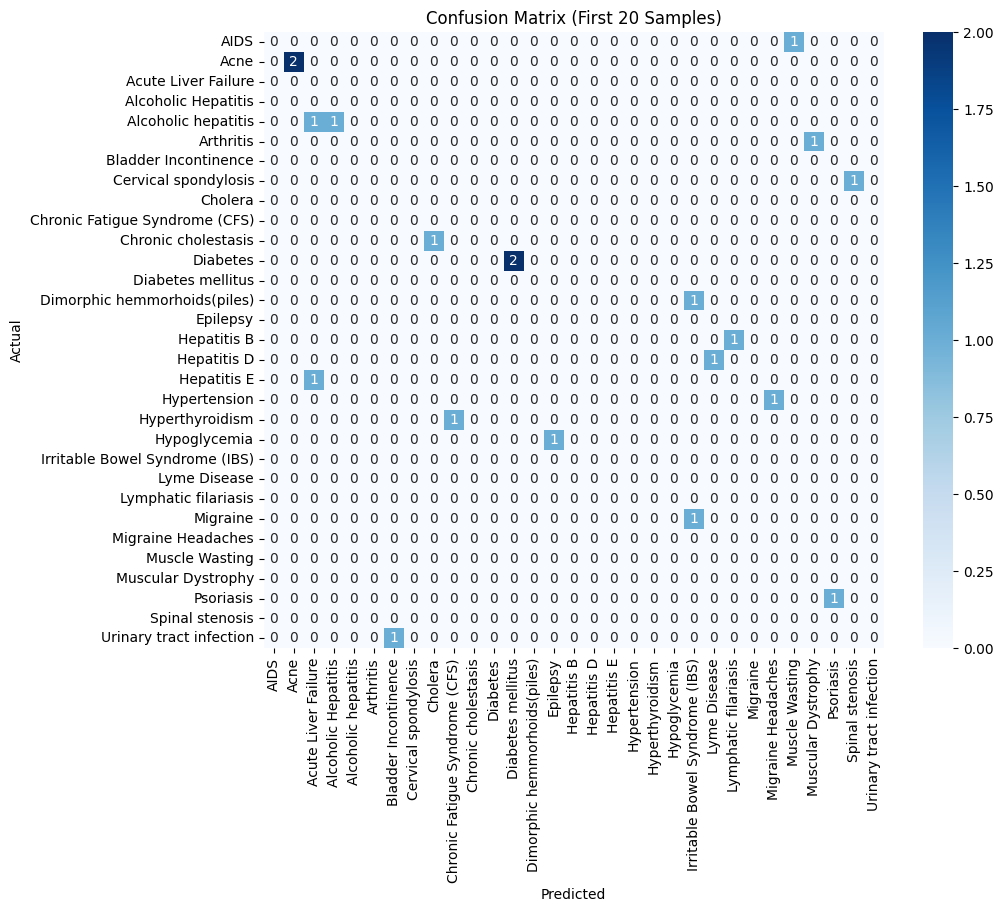

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

labels = sorted(set(y_true) | set(y_pred))  # combine all labels
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (First 20 Samples)")
plt.savefig("confusion_matrix_test20.png", dpi=300)
plt.show()


In [22]:
with open("demo_output.txt", "w") as f:
    for item in test_data[:20]:
        symptoms = item["input"]
        output = generate_output(symptoms)
        f.write(f"Symptoms: {symptoms}\n{output}\n{'-'*50}\n")


In [23]:
from google.colab import files
files.download("demo_output.txt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>